<a href="https://colab.research.google.com/github/arifin220195/Asignment-Machine_Learning-dibimbing/blob/update-streamlit/Assignment_template_DSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries and resources
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle
import joblib

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset = pd.read_csv('/content/drive/MyDrive/dibimbing/assignment/student_scores.csv')
dataset.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [5]:
df = dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


## Exploratory Data Analysis (EDA)
Kita akan memulai dengan memeriksa informasi dasar dataset, seperti tipe data, jumlah nilai non-null, dan statistik deskriptif.

In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicated data
print("\nNumber of duplicated rows:")
print(df.duplicated().sum())

# Display descriptive statistics
print("\nDescriptive statistics:")
display(df.describe())

Missing values per column:
Hours     0
Scores    0
dtype: int64

Number of duplicated rows:
0

Descriptive statistics:


,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


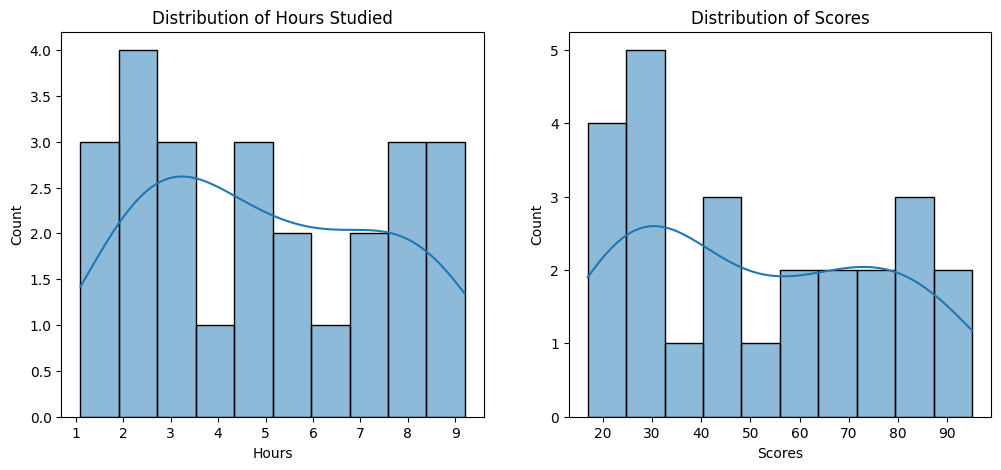

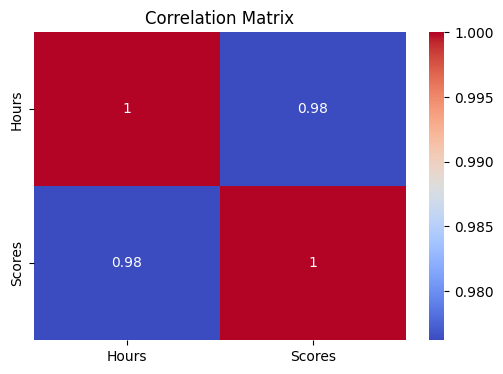

In [7]:
# Histogram distribusi fitur dan target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['Hours'], bins=10, kde=True)
plt.title('Distribution of Hours Studied')

plt.subplot(1,2,2)
sns.histplot(df['Scores'], bins=10, kde=True)
plt.title('Distribution of Scores')
plt.show()

# Heatmap korelasi
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


## Machine Learning Modeling
Kita akan membagi data menjadi training set dan testing set, kemudian melatih model Linear Regression dan Random Forest Regressor.

In [8]:
# Prepare the data
X = df[['Hours']] # Feature
y = df['Scores']  # Target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 20 samples
Testing set size: 5 samples


### Linear Regression Model

In [9]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Coefficient: {lr_model.coef_[0]:.2f}")
print(f"Intercept: {lr_model.intercept_:.2f}")

Linear Regression model trained successfully.
Coefficient: 9.68
Intercept: 2.83


### Random Forest Regressor Model

In [10]:
# Train Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


## Feature Engineering: Outlier Analysis
Kita akan memeriksa apakah ada outlier dalam kolom 'Hours' dan 'Scores' menggunakan box plot.

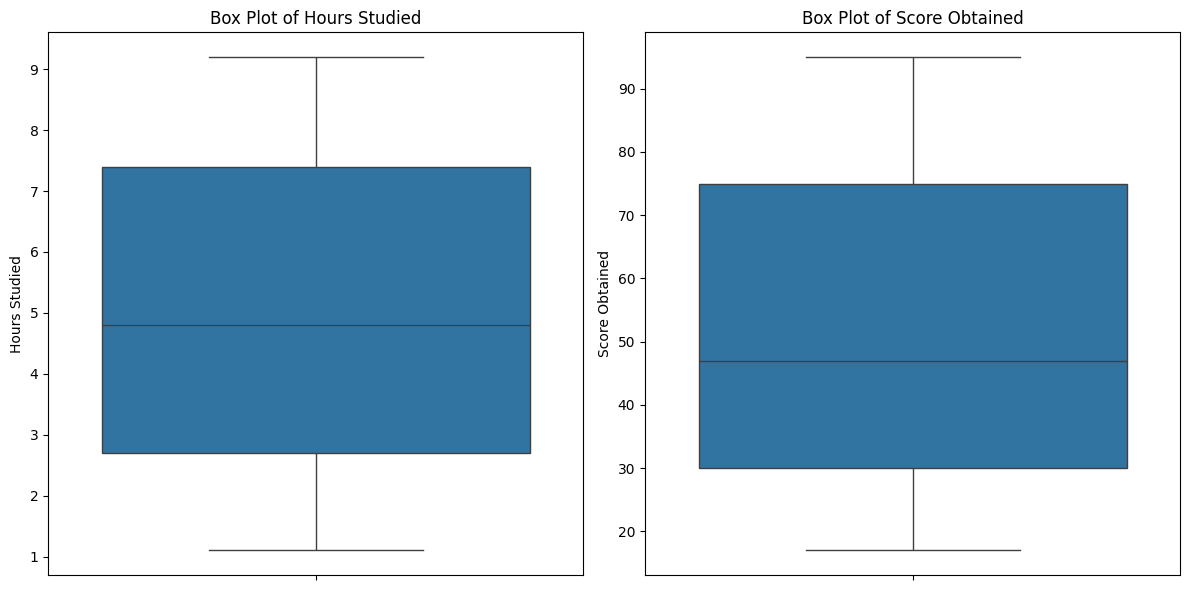

In [11]:
# Check for outliers using box plots
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Hours'])
plt.title('Box Plot of Hours Studied')
plt.ylabel('Hours Studied')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Scores'])
plt.title('Box Plot of Score Obtained')
plt.ylabel('Score Obtained')

plt.tight_layout()
plt.show()

Selanjutnya, mari kita visualisasikan hubungan antara "Hours" dan "Scores" menggunakan scatter plot untuk melihat pola atau korelasi.

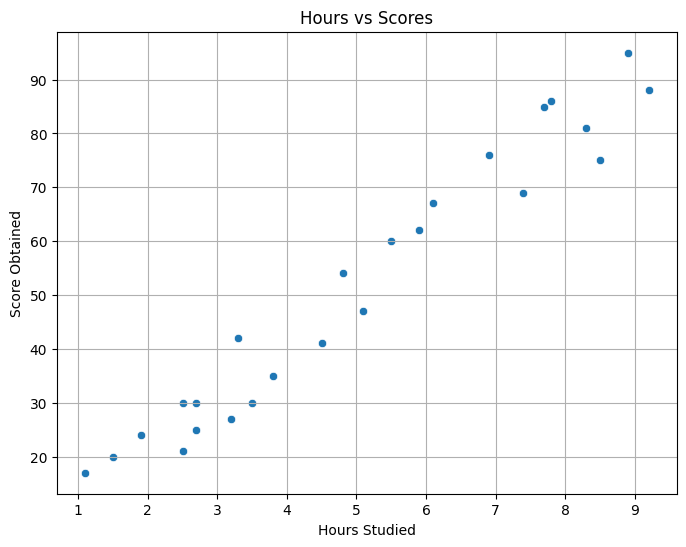

In [12]:
# Visualize the relationship between Hours and Scores
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Hours', y='Scores', data=df)
plt.title('Hours vs Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Score Obtained')
plt.grid(True)
plt.show()

In [13]:
Q1 = df['Hours'].quantile(0.25)
Q3 = df['Hours'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

# Filter out outliers data
df_filtered = df[(df['Hours'] >= lower_bound) & (df['Hours'] <= upper_bound)]
print(df_filtered)


    Hours  Scores
0     2.5      21
1     5.1      47
2     3.2      27
3     8.5      75
4     3.5      30
5     1.5      20
6     9.2      88
7     5.5      60
8     8.3      81
9     2.7      25
10    7.7      85
11    5.9      62
12    4.5      41
13    3.3      42
14    1.1      17
15    8.9      95
16    2.5      30
17    1.9      24
18    6.1      67
19    7.4      69
20    2.7      30
21    4.8      54
22    3.8      35
23    6.9      76
24    7.8      86


## Model Evaluation
Kita akan mengevaluasi performa kedua model menggunakan metrik Mean Squared Error (MSE) dan R-squared pada data testing.

In [14]:
# Evaluate Linear Regression model
lr_pred = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Model Evaluation:")
print(f"Mean Squared Error (MSE): {lr_mse:.2f}")
print(f"R-squared (R2): {lr_r2:.2f}")

Linear Regression Model Evaluation:
Mean Squared Error (MSE): 18.94
R-squared (R2): 0.97


In [15]:
# Evaluate Random Forest Regressor model
rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Regressor Model Evaluation:")
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"R-squared (R2): {rf_r2:.2f}")

# Save y_test and rf_pred
np.save('y_test.npy', y_test)
np.save('rf_pred.npy', rf_pred)


Random Forest Regressor Model Evaluation:
Mean Squared Error (MSE): 13.05
R-squared (R2): 0.98


CV R2 for Linear Regression: 0.918
CV R2 for Random Forest: 0.898


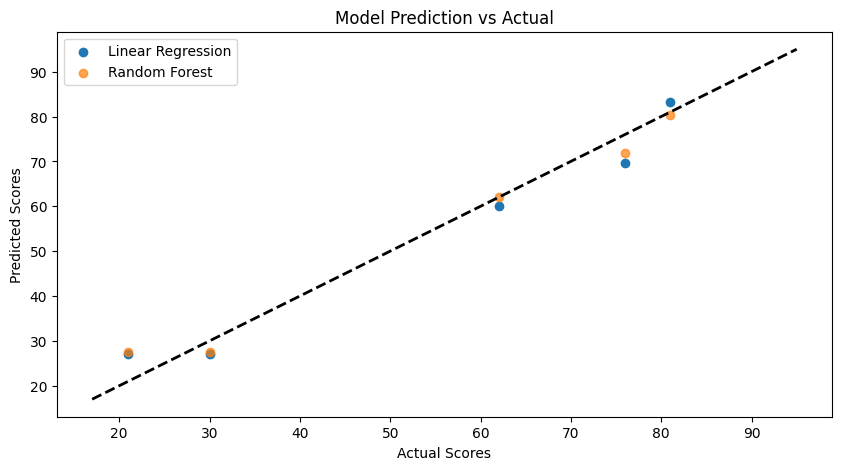

In [16]:
from sklearn.model_selection import cross_val_score

# Cross-validation skor R2
cv_scores_lr = cross_val_score(lr_model, X, y, cv=5, scoring='r2')
cv_scores_rf = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"CV R2 for Linear Regression: {cv_scores_lr.mean():.3f}")
print(f"CV R2 for Random Forest: {cv_scores_rf.mean():.3f}")

# Visualisasi hasil prediksi
plt.figure(figsize=(10,5))
plt.scatter(y_test, lr_pred, label='Linear Regression')
plt.scatter(y_test, rf_pred, label='Random Forest', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Model Prediction vs Actual')
plt.legend()
plt.show()


Penjelasan grafik:

    Sumbu horizontal (x) adalah nilai skor asli (actual scores).

    Sumbu vertikal (y) adalah skor yang diprediksi masing-masing model.

    Titik biru untuk prediksi Linear Regression, titik oranye untuk Random Forest.

    Garis hitam putus-putus adalah garis referensi ideal di mana nilai prediksi sama dengan nilai aktual.

    Titik-titik yang semakin dekat dengan garis ini menandakan prediksi yang semakin akurat.

Interpretasi:

    Kedua model Linear Regression dan Random Forest sudah berhasil memprediksi dengan cukup baik karena titik-titik relatif dekat dengan garis ideal.

    Namun, dengan melihat posisi titik, ada sedikit perbedaan dalam performa keduanya, yang perlu dianalisis lebih lanjut dari metrik evaluasi seperti MSE dan R2.

    Grafik ini membantu visualisasi bagaimana prediksi model menyebar dan apakah ada bias sistematis.

    Grafik itu menunjukkan seberapa akurat prediksi dari dua model (Linear Regression dan Random Forest) dibandingkan nilai sebenarnya.

Mean Squared Error (MSE)

    MSE mengukur rata-rata kuadrat selisih antara nilai prediksi dan nilai aktual.

    Nilai MSE semakin kecil berarti prediksi model semakin akurat dan mendekati nilai asli.

    Karena kuadrat, MSE penalti besar diberikan pada kesalahan prediksi yang jauh dari nilai sebenarnya.

    Contoh: MSE 20 artinya rata-rata kuadrat kesalahan prediksi adalah 20 (unit berbeda tergantung skala target).

R-squared (R2)

    R2 mengukur proporsi variansi target yang dapat dijelaskan oleh model.

    Nilai R2 antara 0 hingga 1, semakin dekat ke 1 semakin baik model menjelaskan variansi data.

    Nilai R2 negatif bisa terjadi jika model sangat buruk.

    Contoh: R2 0.85 berarti model bisa menjelaskan 85% variansi data.

Interpretasi hasil :

    Model dengan MSE lebih kecil dan R2 lebih besar dianggap lebih baik.

    Misal jika Random Forest punya MSE lebih rendah dan R2 lebih tinggi dibanding Linear Regression, maka Random Forest lebih unggul dalam memprediksi skor.

    Visualisasi scatter plot prediksi vs aktual melengkapi analisis, memudahkan melihat pola kesalahan.


Dari hasil pengamatan visualisasi kedua model, pilihan terbaiknya adalah **"Random Forest"**. Informasi lebih detail :



    1. Model Random Forest menunjukkan performa yang lebih baik dengan nilai MSE yang lebih rendah dan nilai R2 yang lebih tinggi dibandingkan Linear Regression. Hal ini menunjukkan bahwa Random Forest mampu menangkap pola hubungan yang lebih kompleks antara variabel jam belajar dengan skor hasil belajar.

    2. Visualisasi prediksi terhadap nilai aktual juga memperlihatkan bahwa model Random Forest menghasilkan prediksi yang lebih dekat dengan data asli dibandingkan Linear Regression.

    3. Cross-validation yang dilakukan juga menguatkan kesimpulan tersebut dengan Random Forest memiliki rata-rata skor R2 lebih tinggi dari Linear Regression, menandakan model ini lebih stabil dan andal dalam memprediksi skor siswa.


In [17]:
with open ('model_DSF.pkl', 'wb') as file_1:
  pickle.dump(rf_model, file_1)

In [18]:
from google.colab import files

files.download('model_DSF.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import joblib

# Save the model using joblib
joblib.dump(rf_model, 'model_DSF.joblib')

# Download the joblib file
from google.colab import files
files.download('model_DSF.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Arahan Assignment
0. Gunakan dataset student score
1. Lakukan proses Exploratory data analysis
2. Lakukan feature engineering :
- Check Duplicated Data
- Check Missing Value Handling
- Outlier Analysis
3. Lakukan modelling machine learning regression : gunakan minimal 2 model (linear regression, decision tree regressor, atau random forest regressor)
4. Lakukan evaluasi model
5. Berikan kesimpulan model mana yang terbaik performanya

In [24]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the page configuration to wide layout and add a theme
st.set_page_config(layout="wide", page_title="Student Score Prediction", page_icon="📊")

# Use a custom CSS for better styling
st.markdown("""
<style>
.main {
    background-color: #f0f2f6;
    padding: 20px;
    border-radius: 10px;
}
.stButton>button {
    background-color: #4CAF50;
    color: white;
    font-weight: bold;
    padding: 10px 20px;
    border-radius: 5px;
    border: none;
    cursor: pointer;
}
.stButton>button:hover {
    background-color: #45a049;
}
.stNumberInput>div>div>input {
    border-radius: 5px;
    padding: 10px;
}
</style>
""", unsafe_allow_html=True)

st.title('📊 Aplikasi Prediksi Skor Siswa')

# Add portfolio description
st.markdown("Ini adalah bagian dari portofolio Machine Learning oleh **Arifin** sebagai hasil latihan dan pembelajaran.")
st.write("""
Repository github : https://github.com/arifin220195/Asignment-Machine_Learning-dibimbing
""")

st.write("""
Aplikasi ini memprediksi skor hasil belajar siswa berdasarkan jumlah jam belajar mereka.
""")

# --- Project Presentation with Features ---

st.header("📘 Langkah-langkah Proyek Analisis Data dan Machine Learning")

st.markdown("Proyek ini bertujuan untuk memprediksi skor hasil belajar siswa berdasarkan jumlah jam belajar menggunakan model Machine Learning.")
st.write("""
Model ini mengambil data dan melatihnya dengan Machine learning dari dataset : "student_scores.csv". Link bisa cek disini : https://drive.google.com/file/d/1nyt0Io8nptuvdeBa9OO6fjUNwUgvwZpy/view?usp=sharing
""")

st.subheader("🔬 1. Exploratory Data Analysis (EDA)")

st.markdown("""
Tahap ini melibatkan pemahaman awal tentang data, termasuk memeriksa informasi dasar, nilai yang hilang, data duplikat, dan statistik deskriptif.
""")

# Display descriptive statistics
try:
    # Assuming the dataframe 'df' is available from notebook execution and contains the original data
    # In a real app, you would load the data here
    dataset = pd.read_csv('/content/drive/MyDrive/dibimbing/assignment/student_scores.csv')
    df = dataset.copy()
    st.write("Descriptive Statistics:")
    st.dataframe(df.describe())

    st.write("Missing Values per Column:")
    st.write(df.isnull().sum())

    st.write("Number of Duplicated Rows:")
    st.write(df.duplicated().sum())

    # Add visualizations from EDA
    st.write("Distribution of Hours Studied and Scores:")
    fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))
    sns.histplot(df['Hours'], bins=10, kde=True, ax=axes1[0])
    axes1[0].set_title('Distribution of Hours Studied')
    sns.histplot(df['Scores'], bins=10, kde=True, ax=axes1[1])
    axes1[1].set_title('Distribution of Scores')
    st.pyplot(fig1)

    st.write("Correlation Matrix:")
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', ax=ax2)
    ax2.set_title('Correlation Matrix')
    st.pyplot(fig2)


except FileNotFoundError:
     st.warning("Could not load dataset for EDA visualization. Please ensure 'student_scores.csv' is in the correct path.")
except Exception as e:
    st.error(f"An error occurred during EDA visualization: {e}")


st.subheader("🔍 2. Feature Engineering: Outlier Analysis")

st.markdown("""
Pada tahap ini, kami memeriksa keberadaan outlier dalam data menggunakan box plot dan scatter plot untuk memvisualisasikan hubungan antar variabel.
""")

try:
    # Check for outliers using box plots
    st.write("Box Plots for Hours Studied and Score Obtained:")
    fig3, axes3 = plt.subplots(1, 2, figsize=(12, 6))
    sns.boxplot(y=df['Hours'], ax=axes3[0])
    axes3[0].set_title('Box Plot of Hours Studied')
    axes3[0].set_ylabel('Hours Studied')
    sns.boxplot(y=df['Scores'], ax=axes3[1])
    axes3[1].set_title('Box Plot of Score Obtained')
    axes3[1].set_ylabel('Score Obtained')
    st.pyplot(fig3)

    # Visualize the relationship between Hours and Scores
    st.write("Scatter Plot of Hours vs Scores:")
    fig4, ax4 = plt.subplots(figsize=(8, 6))
    sns.scatterplot(x='Hours', y='Scores', data=df, ax=ax4)
    ax4.set_title('Hours vs Scores')
    ax4.set_xlabel('Hours Studied')
    ax4.set_ylabel('Score Obtained')
    ax4.grid(True)
    st.pyplot(fig4)

except NameError:
    st.warning("Could not generate Feature Engineering visualizations. Please ensure 'df' is loaded.")
except Exception as e:
    st.error(f"An error occurred during Feature Engineering visualization: {e}")


st.subheader("🤖 3. Machine Learning Modeling")

st.markdown("""
Kami melatih dua model regresi: Linear Regression dan Random Forest Regressor untuk memprediksi skor siswa.
""")

st.subheader("📈 4. Model Evaluation")

st.markdown("""
Performa model dievaluasi menggunakan metrik Mean Squared Error (MSE) dan R-squared (R2) pada data testing.
""")

# Create columns for side-by-side layout for prediction and visualization
col1, col2 = st.columns(2)

with col1:
    # Input from user (Prediction part)
    st.header("🎯 Prediksi Skor")
    hours_studied = st.number_input("Masukkan jumlah jam belajar:", min_value=0.0, max_value=24.0, value=1.0, step=0.1, key='prediction_input')

    # Button to trigger prediction
    if st.button("Prediksi Skor", key='predict_button'):
        # Muat model yang sudah dilatih
        try:
            model = joblib.load('model_DSF.joblib')
            # Create DataFrame from input
            input_data = pd.DataFrame({'Hours': [hours_studied]})

            # Make prediction
            predicted_score = model.predict(input_data)

            # Display prediction result
            st.subheader("✅ Hasil Prediksi:")
            st.info(f"Jika siswa belajar selama {hours_studied} jam, prediksi skornya adalah: **{predicted_score[0]:.2f}**")
        except FileNotFoundError:
            st.error("File model 'model_DSF.joblib' tidak ditemukan. Tidak dapat melakukan prediksi.")
        except Exception as e:
            st.error(f"An error occurred during prediction: {e}")


with col2:
    # Add visualizations (Evaluation part)
    st.header("📊 Visualisasi Performa Model (Random Forest)")

    # Load y_test and rf_pred for visualization
    try:
        y_test_viz = np.load('y_test.npy')
        rf_pred_viz = np.load('rf_pred.npy')
        fig_eval, ax_eval = plt.subplots(figsize=(10, 5))
        ax_eval.scatter(y_test_viz, rf_pred_viz, label='Random Forest', alpha=0.7)
        ax_eval.plot([min(y_test_viz), max(y_test_viz)], [min(y_test_viz), max(y_test_viz)], 'k--', lw=2)
        ax_eval.set_xlabel('Actual Scores')
        ax_eval.set_ylabel('Predicted Scores')
        ax_eval.set_title('Model Prediction vs Actual (Random Forest)')
        ax_eval.legend()
        st.pyplot(fig_eval)
    except FileNotFoundError:
        st.warning("Could not load y_test and rf_pred for visualization. Please run the model evaluation step in the notebook and ensure 'y_test.npy' and 'rf_pred.npy' are saved.")
    except Exception as e:
         st.error(f"An error occurred during visualization: {e}")


st.subheader("📝 5. Kesimpulan")

st.markdown("""
Dari hasil pengamatan visualisasi dan metrik evaluasi (MSE dan R2), model **Random Forest** menunjukkan performa yang lebih baik dibandingkan Linear Regression dalam memprediksi skor siswa berdasarkan jam belajar.

*   **Mean Squared Error (MSE)**: Mengukur rata-rata kuadrat selisih antara nilai prediksi dan nilai aktual. Nilai MSE yang lebih rendah menunjukkan akurasi prediksi yang lebih tinggi.
*   **R-squared (R2)**: Mengukur proporsi variansi target yang dapat dijelaskan oleh model. Nilai R2 yang lebih tinggi (mendekati 1) menunjukkan bahwa model lebih baik dalam menjelaskan variasi data.

Model Random Forest memiliki MSE yang lebih rendah dan R2 yang lebih tinggi, serta visualisasi prediksinya lebih dekat dengan data aktual, menjadikannya pilihan terbaik untuk kasus ini.
""")

Overwriting app.py


In [21]:
# Install streamlit and pyngrok
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 79.8 MB/s eta 0:00:00


In [22]:
# Run streamlit app and expose with ngrok
from pyngrok import ngrok
import os
from google.colab import userdata

# Set ngrok authtoken from Colab secrets
try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
except Exception as e:
    print(f"Error loading ngrok authtoken: {e}")
    print("Please make sure you have added your NGROK_AUTH_TOKEN to Colab secrets.")
    NGROK_AUTH_TOKEN = None


if NGROK_AUTH_TOKEN:
    # Kill any running ngrok tunnels
    ngrok.kill()

    # Start a Streamlit app tunnel
    # We run in the background and suppress output
    get_ipython().system_raw('streamlit run app.py &')


    # Get the public URL
    try:
        public_url = ngrok.connect(8501).public_url
        print(f"Streamlit App URL: {public_url}")
    except Exception as e:
        print(f"Error connecting to ngrok tunnel: {e}")
else:
    print("Cannot run Streamlit app without ngrok authtoken.")

Streamlit App URL: https://unguidedly-nongenerative-penni.ngrok-free.dev
